In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("silviamatoke/serengeti-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'serengeti-dataset' dataset.
Path to dataset files: /kaggle/input/serengeti-dataset


Total species: 22
Total subdirectories: 1955
Total images: 24673

Sample species data:
              Species                                       Subdirectory  \
0   serengeti-dataset               /kaggle/input/serengeti-dataset/Set1   
1                Set1  /kaggle/input/serengeti-dataset/Set1/1.63-Euro...   
2  1.63-European_Hare  /kaggle/input/serengeti-dataset/Set1/1.63-Euro...   
3  1.63-European_Hare  /kaggle/input/serengeti-dataset/Set1/1.63-Euro...   
4  1.63-European_Hare  /kaggle/input/serengeti-dataset/Set1/1.63-Euro...   

   Image Count  
0            0  
1            0  
2           10  
3            5  
4            5  


/tmp/ipython-input-1844629067.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='Image Count', data=df_species, palette='viridis')


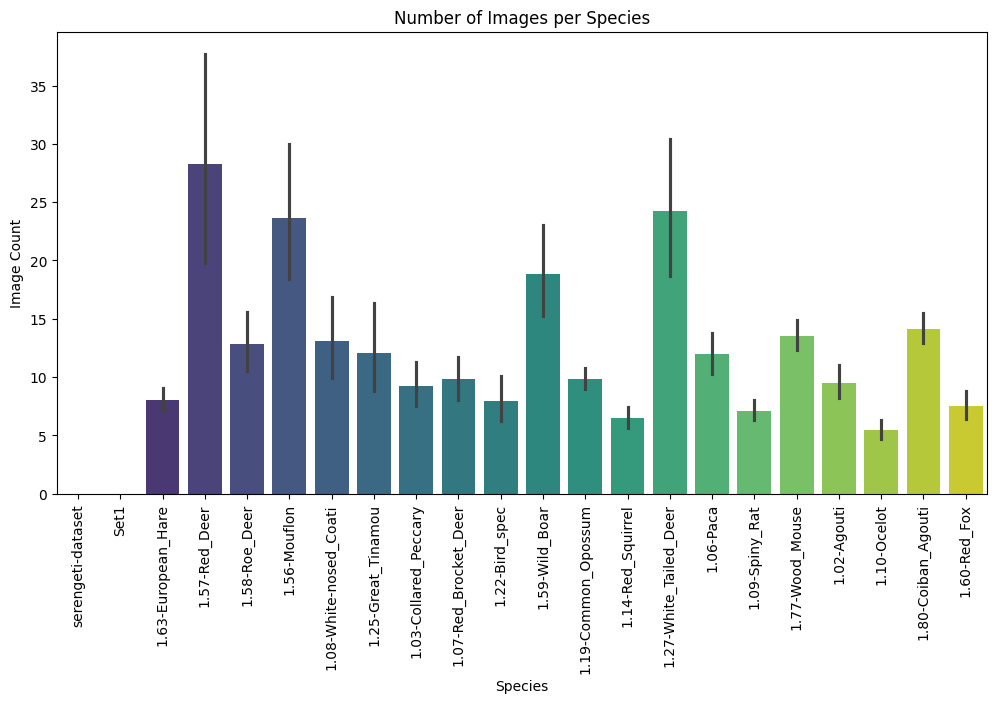

/tmp/ipython-input-1844629067.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='Subdirectory Count', data=subdir_count_df, palette='coolwarm')


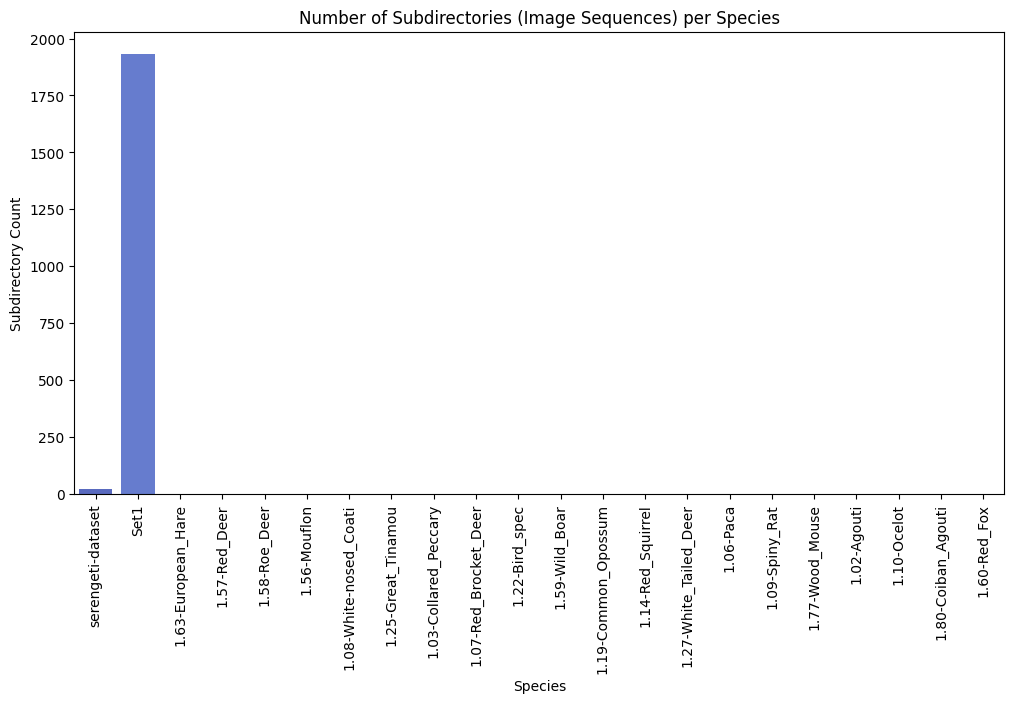

/tmp/ipython-input-1844629067.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='Image Count', data=avg_images_per_subdir, palette='Blues')


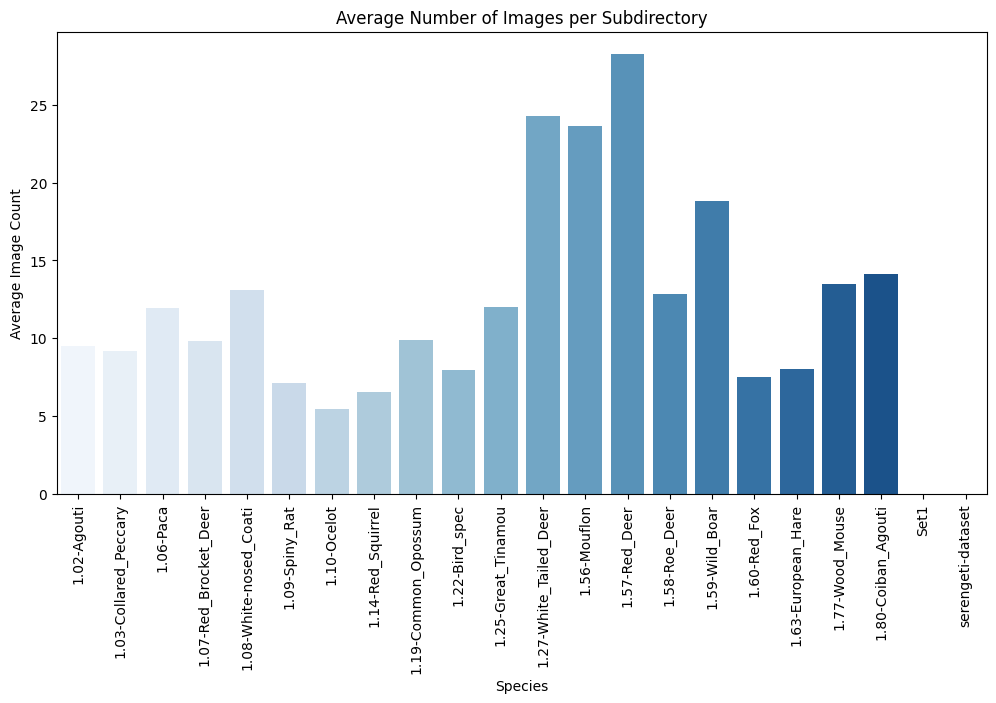

Species with the highest number of images: 1.57-Red_Deer (2830 images)
Species with the lowest number of images: serengeti-dataset (0 images)


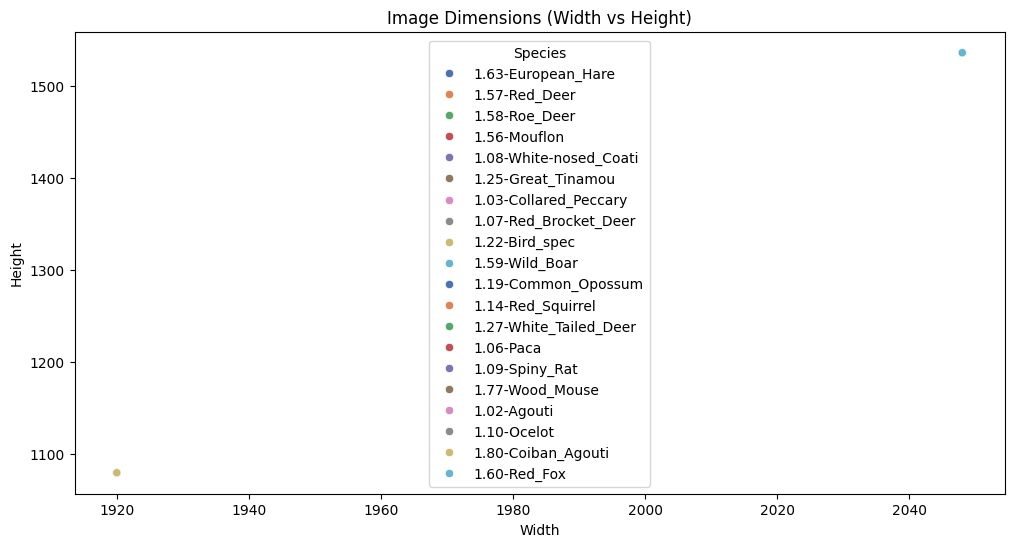

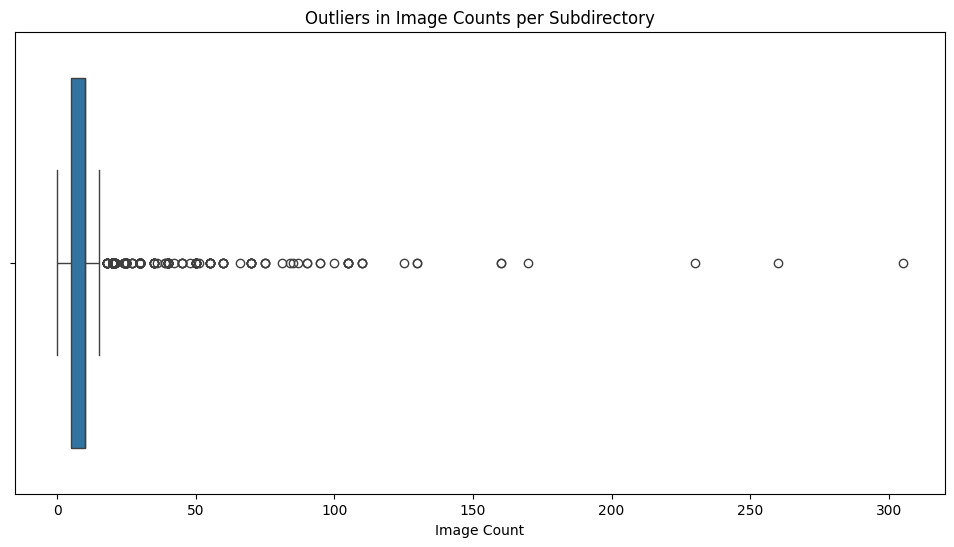

/tmp/ipython-input-1844629067.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Species', y='Image Count', data=df_species_per_class, palette='viridis')


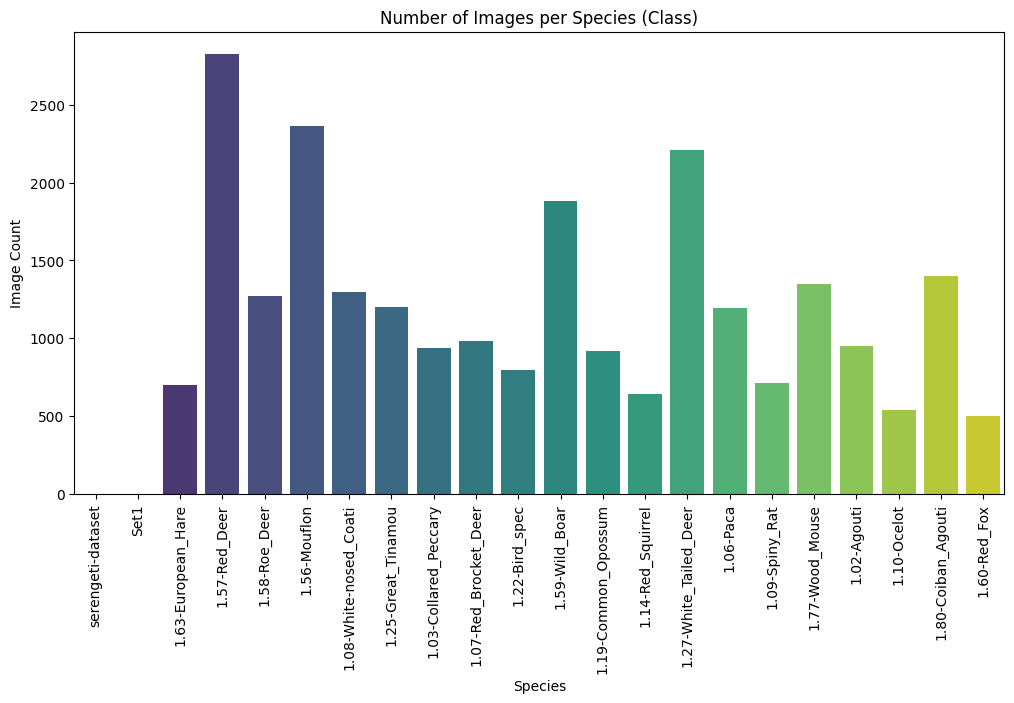

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

# Set the path to your Serengeti dataset
dataset_path = '/kaggle/input/serengeti-dataset'

# Function to recursively perform EDA on Serengeti dataset
def perform_eda_recursive(base_path):
    species_data = []  # List to hold species info
    species_image_count = {}  # Dictionary to store image counts per species
    subdir_counts = {}  # Dictionary to store counts of subdirectories per species
    image_sizes = []  # List to store image sizes (width, height)

    # Walk through each species directory recursively
    for root, dirs, files in os.walk(base_path):
        # Skip the root directory itself
        if root == base_path:
            continue

        # Get the species name (it's the top-level directory, the first part of the path)
        species_name = root.split('/')[-2]

        # Count image files in the current directory (subdirectory within species directory)
        image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        image_count = len(image_files)

        # Store data for each subdirectory (image sequence)
        species_data.append((species_name, root, image_count))

        # Update the total count of images per species
        if species_name not in species_image_count:
            species_image_count[species_name] = 0
        species_image_count[species_name] += image_count

        # Count subdirectories per species
        if species_name not in subdir_counts:
            subdir_counts[species_name] = 0
        subdir_counts[species_name] += len(dirs)

        # Store image sizes (width, height) if images are available
        for image_file in image_files:
            image_path = os.path.join(root, image_file)
            try:
                with Image.open(image_path) as img:
                    width, height = img.size
                    image_sizes.append((species_name, width, height))
            except Exception as e:
                print(f"Error reading {image_file}: {e}")

    # Convert species data to a DataFrame for easier visualization
    df_species = pd.DataFrame(species_data, columns=['Species', 'Subdirectory', 'Image Count'])

    # Summary statistics
    print(f"Total species: {len(species_image_count)}")
    print(f"Total subdirectories: {len(df_species)}")
    print(f"Total images: {df_species['Image Count'].sum()}")

    # Display some of the species data
    print("\nSample species data:")
    print(df_species.head())

    # 1. Plot the distribution of images per species (based on subdirectories)
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Species', y='Image Count', data=df_species, palette='viridis')
    plt.title('Number of Images per Species')
    plt.xticks(rotation=90)
    plt.xlabel('Species')
    plt.ylabel('Image Count')
    plt.show()

    # 2. Distribution of subdirectories (image sequences) per species
    subdir_count_df = pd.DataFrame(list(subdir_counts.items()), columns=['Species', 'Subdirectory Count'])
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Species', y='Subdirectory Count', data=subdir_count_df, palette='coolwarm')
    plt.title('Number of Subdirectories (Image Sequences) per Species')
    plt.xticks(rotation=90)
    plt.xlabel('Species')
    plt.ylabel('Subdirectory Count')
    plt.show()

    # 3. Average number of images per subdirectory per species
    avg_images_per_subdir = df_species.groupby('Species')['Image Count'].mean().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Species', y='Image Count', data=avg_images_per_subdir, palette='Blues')
    plt.title('Average Number of Images per Subdirectory')
    plt.xticks(rotation=90)
    plt.xlabel('Species')
    plt.ylabel('Average Image Count')
    plt.show()

    # 4. Species with the highest and lowest image counts
    max_images_species = max(species_image_count, key=species_image_count.get)
    min_images_species = min(species_image_count, key=species_image_count.get)
    print(f"Species with the highest number of images: {max_images_species} ({species_image_count[max_images_species]} images)")
    print(f"Species with the lowest number of images: {min_images_species} ({species_image_count[min_images_species]} images)")

    # 5. Outliers in image counts (boxplot)
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Image Count', data=df_species)
    plt.title('Outliers in Image Counts per Subdirectory')
    plt.xlabel('Image Count')
    plt.show()

    # Plot the number of images per species (focused plot for images per class)
    df_species_per_class = pd.DataFrame(list(species_image_count.items()), columns=['Species', 'Image Count'])
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Species', y='Image Count', data=df_species_per_class, palette='viridis')
    plt.title('Number of Images per Species (Class)')
    plt.xticks(rotation=90)
    plt.xlabel('Species')
    plt.ylabel('Image Count')
    plt.show()

# Call the function to perform EDA
perform_eda_recursive(dataset_path)
